# Q_1: Housing Prices
Load clean q1_clean: https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv 

The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighborhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented


In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [67]:
url = "https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv"

data = pd.read_csv(url)

# there are unwanted characters in the column headers that we need to remove
data.columns = data.columns.str.strip()

data.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


Now the data is cleaned and we can move on to answering the questions.

## 1. Compute the average prices and scores by `Neighborhood`; which borough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighborhood`.

In [68]:
averages = data.groupby("Neighbourhood")[["Price" , "Review Scores Rating" ]].mean()
print(averages.sort_values("Price", ascending=False))

# Manhattan is the most expensive on average

                    Price  Review Scores Rating
Neighbourhood                                  
Manhattan      183.664286             91.801496
Staten Island  146.166667             90.843750
Brooklyn       127.747378             92.363497
Queens          96.857233             91.549057
Bronx           75.276498             91.654378


Text(0.5, 1.0, 'KDE of Log Price by Neighbourhood')

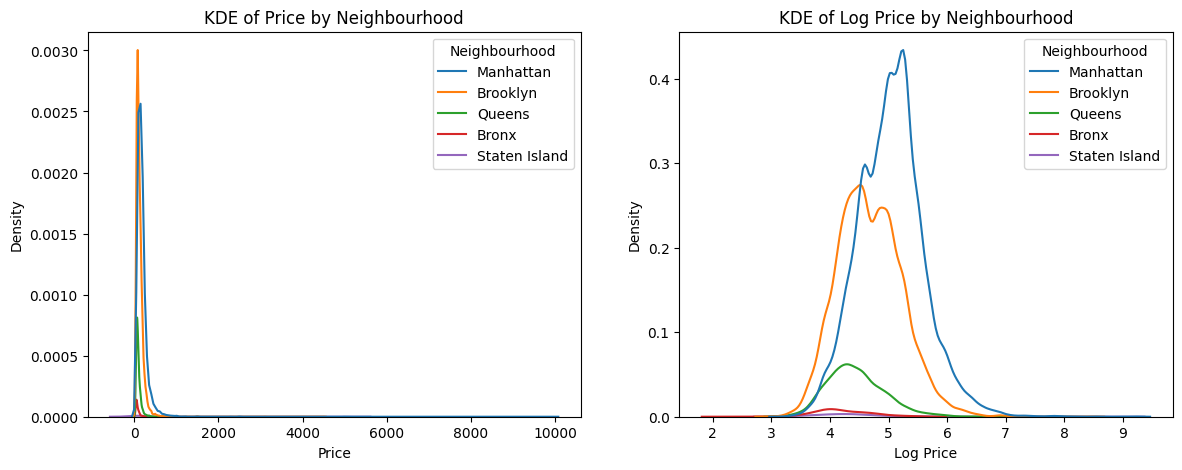

In [69]:
data["Log Price"] = np.log(data["Price"])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data, x = "Price" , hue= "Neighbourhood" , ax = axes[0])
axes[0].set_title("KDE of Price by Neighbourhood")

sns.kdeplot(data, x = "Log Price" , hue= "Neighbourhood" , ax = axes[1])
axes[1].set_title("KDE of Log Price by Neighbourhood")

## 2. Regress price on `Neighborhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?

In [70]:
# we will need to adjust some variables to category variables
house_raw = data.copy()
house_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 22153 entries, 0 to 22152
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Price                 22153 non-null  int64  
 1   Review Scores Rating  22153 non-null  float64
 2   Neighbourhood         22153 non-null  str    
 3   Property Type         22153 non-null  str    
 4   Room Type             22153 non-null  str    
 5   Log Price             22153 non-null  float64
dtypes: float64(2), int64(1), str(3)
memory usage: 1.0 MB


In [71]:
# we need to make certain variables into categorical vars
cat_vars = ['Neighbourhood' , 'Property Type' , 'Room Type']
house_raw[cat_vars] = house_raw[cat_vars].astype("category")
house_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 22153 entries, 0 to 22152
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Price                 22153 non-null  int64   
 1   Review Scores Rating  22153 non-null  float64 
 2   Neighbourhood         22153 non-null  category
 3   Property Type         22153 non-null  category
 4   Room Type             22153 non-null  category
 5   Log Price             22153 non-null  float64 
dtypes: category(3), float64(2), int64(1)
memory usage: 584.4 KB


In [72]:
# There are too many categories to one-hot-encode
# lets consolidate
print(house_raw["Property Type"].value_counts())

Property Type
Apartment          19656
House               1559
Loft                 591
Bed & Breakfast      136
Townhouse             83
Condominium           48
Other                 28
Dorm                  22
Boat                   6
Camper/RV              6
Villa                  6
Bungalow               3
Treehouse              3
Cabin                  2
Castle                 1
Chalet                 1
Hut                    1
Lighthouse             1
Name: count, dtype: int64


In [73]:
# Consolidation of categories
keep = ["Apartment" , "House"]

house_raw["Property Type"] = np.where(house_raw["Property Type"].isin(keep), 
                                      house_raw["Property Type"],
                                       "Other" )

print(house_raw["Property Type"].value_counts())

# neighbourhood and room type do not need this as they both have less than 5 categories

Property Type
Apartment    19656
House         1559
Other          938
Name: count, dtype: int64


In [74]:
# need to create one-hot-encoded variables for the other categories
house_consolidated = house_raw.copy()
house_consolidated = pd.get_dummies(house_consolidated,
                           columns= ['Property Type' , 'Room Type'] , 
                           drop_first=True, 
                           prefix=["prop", "room"]
                           )

In [75]:
X_simple = pd.get_dummies(house_consolidated["Neighbourhood"], drop_first=False, prefix='hood') 
y_target = house_consolidated["Price"]

# Without intercept
model_without = LinearRegression(fit_intercept=False).fit(X_simple, y_target)

In [76]:
coefficients = pd.Series(model_without.coef_, index=X_simple.columns)

In [77]:
print("Intercept:", model_without.intercept_)
print("Coefficients:\n", coefficients.sort_values(ascending=False))

Intercept: 0.0
Coefficients:
 hood_Manhattan        183.664286
hood_Staten Island    146.166667
hood_Brooklyn         127.747378
hood_Queens            96.857233
hood_Bronx             75.276498
dtype: float64


In [78]:
print(averages.sort_values("Price", ascending=False))

                    Price  Review Scores Rating
Neighbourhood                                  
Manhattan      183.664286             91.801496
Staten Island  146.166667             90.843750
Brooklyn       127.747378             92.363497
Queens          96.857233             91.549057
Bronx           75.276498             91.654378


The coefficients of each neighbourhood is the same as the average of that same neigbourhood. The coefficient of a continuous variable on a categorical variable tells you the group average (without incercept).

## 3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?

In [79]:
X_simple = pd.get_dummies(house_consolidated["Neighbourhood"], drop_first=True, prefix='hood') 
y_target = house_consolidated["Price"]

# Without intercept
model_with = LinearRegression(fit_intercept=True).fit(X_simple, y_target)

In [80]:
coefficients = pd.Series(model_with.coef_, index=X_simple.columns)

In [81]:
print("Intercept:", model_with.intercept_)
print("Coefficients:\n", coefficients.sort_values(ascending=False))

Intercept: 75.27649769585331
Coefficients:
 hood_Manhattan        108.387789
hood_Staten Island     70.890169
hood_Brooklyn          52.470881
hood_Queens            21.580735
dtype: float64


You need to drop the first category. The intercept is equal to the average of the column that was dropped. In this case it was the bronx. The coefficients are the difference between their groups average and the bronx average. You can get the coefficients in part 2 by added the intercept to the coefficient found in part 3.

## 4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?

In [82]:
house_consolidated = pd.get_dummies(house_consolidated, drop_first=True, columns= ["Neighbourhood"] , prefix= "hood")

In [83]:
cols = ['Review Scores Rating', 'hood_Brooklyn',
       'hood_Manhattan', 'hood_Queens', 'hood_Staten Island']

X_final = house_consolidated[cols]
y_final = house_consolidated.loc[X_final.index, 'Price']

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42)

In [84]:
model = LinearRegression(fit_intercept=True).fit(X_train, y_train)
y_pred = model.predict(X_test)

In [85]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")


Mean Squared Error (MSE): 19857.94
Root Mean Squared Error (RMSE): 140.92
R² Score: 0.0459


In [86]:
coefficients = pd.Series(model.coef_, index=X_train.columns)

In [87]:
print("Intercept:", model.intercept_)
print("Coefficients:\n", coefficients.sort_values(ascending=False))

Intercept: -35.157344063247564
Coefficients:
 hood_Manhattan          107.413553
hood_Brooklyn            51.555970
hood_Staten Island       23.454672
hood_Queens              20.198573
Review Scores Rating      1.211852
dtype: float64


The $R^2$ is 0.046 and RMSE is 140.92. These are not very good numbers. The coefficient on Review Scores Rating is 1.212. The most expensive kind of property that you can rent is in manhattan.

## 5. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?

In [88]:
cols = ['Review Scores Rating', 'prop_House',
       'prop_Other', 'hood_Brooklyn',
       'hood_Manhattan', 'hood_Queens', 
       'hood_Staten Island']

X_final = house_consolidated[cols]
y_final = house_consolidated.loc[X_final.index, 'Price']

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42)

In [89]:
model = LinearRegression(fit_intercept=True).fit(X_train, y_train)
y_pred = model.predict(X_test)

In [90]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Squared Error (MSE): 19729.92
Root Mean Squared Error (RMSE): 140.46
R² Score: 0.0521


In [91]:
coefficients = pd.Series(model.coef_, index=X_train.columns)

In [92]:
print("Intercept:", model.intercept_)
print("Coefficients:\n", coefficients.sort_values(ascending=False))

Intercept: -51.854520598600374
Coefficients:
 hood_Manhattan          120.915149
hood_Brooklyn            59.908076
prop_Other               47.654376
prop_House               34.959854
hood_Queens              25.070341
hood_Staten Island       15.527615
Review Scores Rating      1.229409
dtype: float64


The $R^2$ is 0.052 and RMSE is 140.46. These are still not very good numbers. The coefficient on Review Scores Rating is 1.229. The most expensive place to rent a property is manhattan. Compared to other kinds of properties, the "other" category is the most expensive kind of property. This means that if the property is not an apartment or house then it will likely be more expensive.

## 6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multiple linear regression works.



This means that in part 5 the review scores rating has more weight than in part 4. Assuming that all other features stay constant, in both examples, a change in review score rating in part 5 will have more of an impact on the predicted price compared to its impact on predicted price in part 4.